In [5]:
import cv2
import numpy as np 
print("Successfully imported")

Successfully imported


In [6]:
import zipfile
import os


In [6]:
with zipfile.ZipFile("DeepGlobe_Road.zip",'r') as zip_ref:
    zip_ref.extractall("DeepGlobe_Dataset")

In [7]:
print(os.listdir("DeepGlobe_Dataset"))

['class_dict.csv', 'metadata.csv', 'test', 'train', 'valid']


In [8]:
print(os.listdir("DeepGlobe_Dataset/train"))

['100034_mask.png', '100034_sat.jpg', '100081_mask.png', '100081_sat.jpg', '100129_mask.png', '100129_sat.jpg', '100703_mask.png', '100703_sat.jpg', '100712_mask.png', '100712_sat.jpg', '100773_mask.png', '100773_sat.jpg', '100841_mask.png', '100841_sat.jpg', '100867_mask.png', '100867_sat.jpg', '100892_mask.png', '100892_sat.jpg', '101225_mask.png', '101225_sat.jpg', '101296_mask.png', '101296_sat.jpg', '101395_mask.png', '101395_sat.jpg', '102408_mask.png', '102408_sat.jpg', '10246_mask.png', '10246_sat.jpg', '10255_mask.png', '10255_sat.jpg', '102699_mask.png', '102699_sat.jpg', '102925_mask.png', '102925_sat.jpg', '102945_mask.png', '102945_sat.jpg', '103056_mask.png', '103056_sat.jpg', '103201_mask.png', '103201_sat.jpg', '103341_mask.png', '103341_sat.jpg', '103447_mask.png', '103447_sat.jpg', '103627_mask.png', '103627_sat.jpg', '103722_mask.png', '103722_sat.jpg', '104350_mask.png', '104350_sat.jpg', '104607_mask.png', '104607_sat.jpg', '10466_mask.png', '10466_sat.jpg', '10468

Total images: 6226


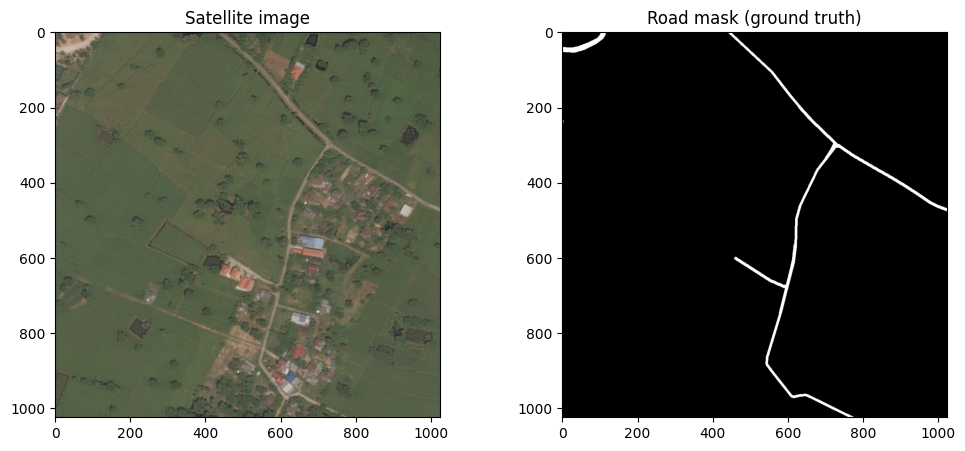

In [26]:
import matplotlib.pyplot as plt
data_dir = "DeepGlobe_Dataset/train"
samples = [f.replace("_sat.jpg", "") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
print(f"Total images: {len(samples)}")
# Visualize one sample
idx = samples[3]
sat = cv2.imread(f"{data_dir}/{idx}_sat.jpg")
mask = cv2.imread(f"{data_dir}/{idx}_mask.png", cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(sat, cv2.COLOR_BGR2RGB))
axes[0].set_title("Satellite image")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Road mask (ground truth)")
plt.show()


In [11]:
def fragment_image(img_id, img, overlap=0.35, rows=3, cols=3):
    if img is None :
        raise ValueError("Image not loaded")
    h, w = img.shape[:2]
    frag_h = int(h / (1 + (rows - 1) * (1 - overlap)))
    frag_w = int(w / (1 + (cols - 1) * (1 - overlap)))
    fragments = []
    for i in range(rows):
        for j in range(cols):
            y1 = int(i * frag_h * (1 - overlap))
            x1 = int(j * frag_w * (1 - overlap))
            y2 = min(y1 + frag_h, h)
            x2 = min(x1 + frag_w, w)
            frag = img[y1:y2, x1:x2]
            fragments.append({
                "img_id": img_id,       # which map this came from
                "grid_pos": (i, j),     # ground truth position
                "x1": x1, "y1": y1,
                "x2": x2, "y2": y2,
                "image": frag
            })
    return fragments

In [13]:
import json
import random

def create_dataset(data_dir, out_dir, num_maps=5, overlap=0.35):
    os.makedirs(out_dir, exist_ok=True)
    samples = [f.replace("_sat.jpg","") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
    selected = random.sample(samples, min(num_maps, len(samples)))

    all_fragments = []
    metadata = []

    for img_id in selected:
        img = cv2.imread(f"{data_dir}/{img_id}_sat.jpg")
        frags = fragment_image(img_id, img, overlap=overlap)
        all_fragments.extend(frags)

    #shuffle 
    random.shuffle(all_fragments)

    for idx, frag in enumerate(all_fragments):
        fname = f"frag_{idx:04d}.jpg"
        cv2.imwrite(f"{out_dir}/{fname}", frag["image"])
        metadata.append({
            "file": fname,
            "img_id": frag["img_id"],
            "grid_pos": list(frag["grid_pos"]),
            "x1": frag["x1"], "y1": frag["y1"],
            "x2": frag["x2"], "y2": frag["y2"]
        })

    with open(f"{out_dir}/metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"Created {len(all_fragments)} fragments from {len(selected)} maps")
    return metadata


In [18]:
out_dir = "DeepGlobe_Dataset/fragments"
metadata = create_dataset(data_dir, out_dir)

Created 45 fragments from 5 maps


In [17]:
def show_fragments(out_dir, num=6):
    files = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]

    plt.figure(figsize=(10, 6))

    for i in range(min(num, len(files))):
        img_path = os.path.join(out_dir, files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(files[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

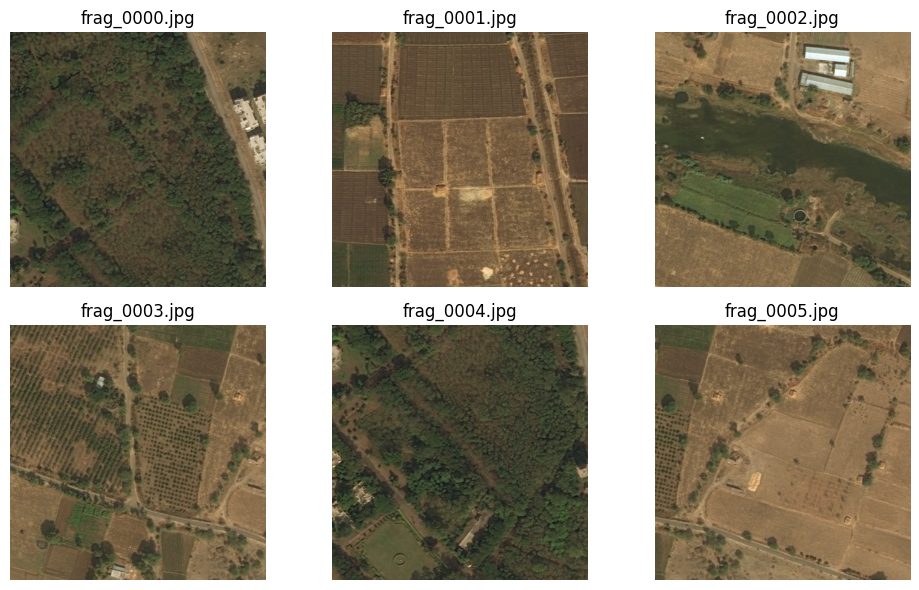

In [31]:
show_fragments(out_dir)

In [ ]:
samples_1 = [f.replace("_sat.jpg","") for f in os.listdir(data_dir) if f.endswith("_sat.jpg")]
print(len(samples_1))

6226


In [25]:
samples_2 = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]
print(len(samples_2))

45


#why ids it bgr in cv ?
#what is hsv
#diff btww bgr and hsv

# Step 1: Feature Extraction

In [51]:
def extract_features(img) :
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(nfeatures = 2000) #nfeatures = 2000
    keypoints, descriptors = orb.detectAndCompute(img_gray, None)
    return keypoints, descriptors

# Testing
files = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]
img_path = os.path.join(out_dir, files[1])
frag = cv2.imread(img_path)
kp, des = extract_features(frag)
print(f"keypoints found : {len(kp)}")

keypoints found : 1620


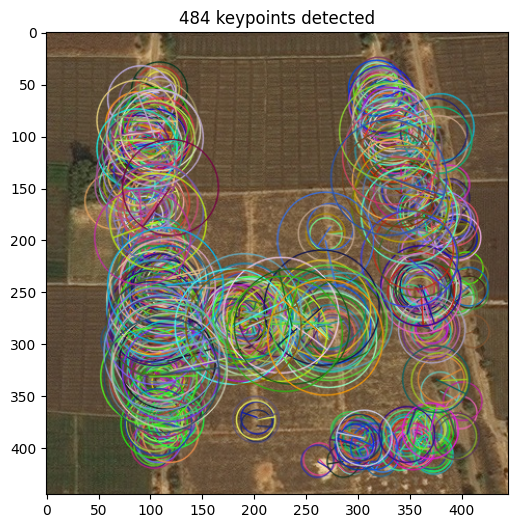

In [65]:
# Visualize keypoints
vis = cv2.drawKeypoints(frag, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"{len(kp)} keypoints detected")
plt.show()

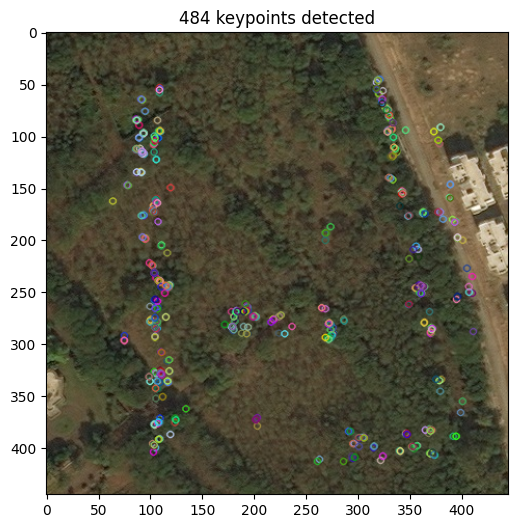

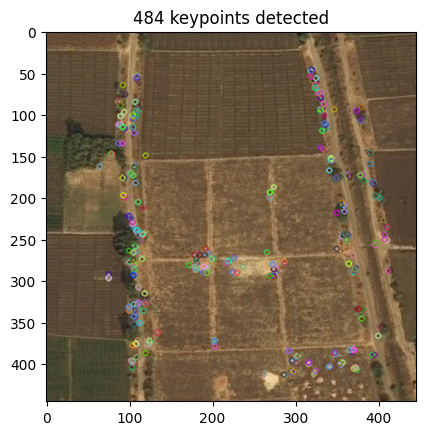

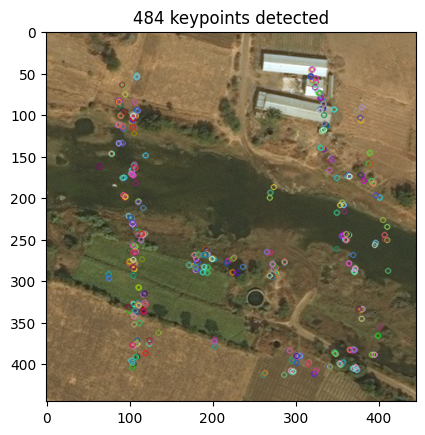

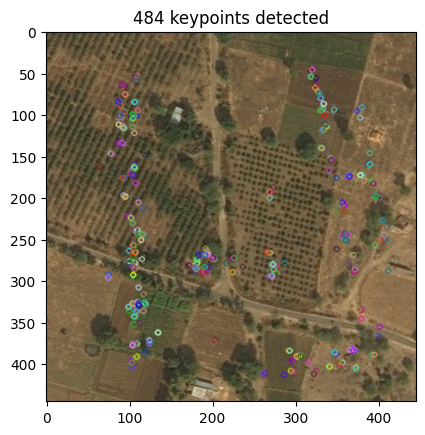

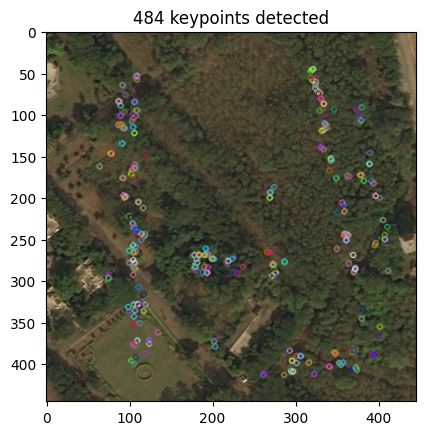

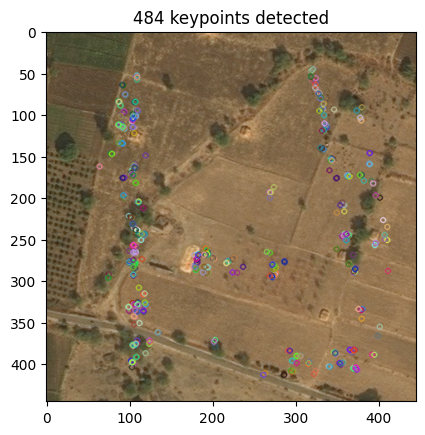

In [66]:
def show_keypoints(out_dir, num=6):
    files = [f for f in os.listdir(out_dir) if f.endswith(".jpg")]

    plt.figure(figsize=(10, 6))

    for i in range(min(num, len(files))):
        img_path = os.path.join(out_dir, files[i])
        frag = cv2.imread(img_path)
        vis = cv2.drawKeypoints(frag, kp, None, flags=0) #cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"{len(kp)} keypoints detected")
        plt.show()

show_keypoints(out_dir)

# Step 2 : Matching and Grouping 

In [ ]:
import cv2
import numpy as np
import os
from itertools import combinations

# 1. Improved ORB + preprocessing
def extract_features(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Contrast boost
    img_gray = cv2.equalizeHist(img_gray)

    orb = cv2.ORB_create(
        nfeatures=3000,
        scaleFactor=1.2,
        nlevels=8,
        edgeThreshold=15,
        patchSize=31
    )

    keypoints, descriptors = orb.detectAndCompute(img_gray, None)
    return keypoints, descriptors


# 2. Robust matching (KNN + fallback)
def match_pair(desc1, desc2):
    if desc1 is None or desc2 is None:
        return 0, []

    # KNN matching
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(desc1, desc2, k=2)

    good = []
    for pair in matches:
        if len(pair) < 2:
            continue
        m, n = pair

        # ratio test
        if m.distance < 0.9 * n.distance:
            good.append(m)

    # fallback if KNN fails
    if len(good) < 6:
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        good_matches = bf.match(desc1, desc2)
        good_matches = sorted(good_matches, key=lambda x: x.distance)[:20]

    return len(good_matches), good_matches


# 3. Homography with relaxed threshold
def compute_homography(kp1, kp2, good_matches, min_matches=6):
    if len(good_matches) < min_matches:
        return None, 0

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    inliers = int(mask.sum()) if mask is not None else 0
    return H, inliers


# 4. Load fragments
frag_files = sorted([f for f in os.listdir("DeepGlobe_Dataset/fragments") if f.endswith(".jpg")])

fragments = []
for fname in frag_files:
    img = cv2.imread(f"DeepGlobe_Dataset/fragments/{fname}")
    kp, desc = extract_features(img)
    fragments.append({
        "file": fname,
        "img": img,
        "kp": kp,
        "desc": desc
    })

print(f"Loaded {len(fragments)} fragments")


# 5. Build overlap graph (LESS STRICT)
MIN_INLIERS = 100
edges = []

for i, j in combinations(range(len(fragments)), 2):

    # same image 
    if i == j:
        continue

    n_matches, good = match_pair(fragments[i]["desc"], fragments[j]["desc"])

    print(f"{frag_files[i]} vs {frag_files[j]} → matches: {n_matches}")

    if n_matches >= 6:
        H, inliers = compute_homography(
            fragments[i]["kp"],
            fragments[j]["kp"],
            good
        )

        print(f"   inliers: {inliers}")

        if H is not None and inliers >= MIN_INLIERS:
            edges.append((i, j, H, inliers))
            print(f"  Match: {frag_files[i]} <-> {frag_files[j]} ({inliers} inliers)")

print(f"\n Total valid pairs: {len(edges)}")

Loaded 45 fragments
frag_0000.jpg vs frag_0001.jpg → matches: 335
   inliers: 8
frag_0000.jpg vs frag_0002.jpg → matches: 337
   inliers: 12
frag_0000.jpg vs frag_0003.jpg → matches: 382
   inliers: 8
frag_0000.jpg vs frag_0004.jpg → matches: 746
   inliers: 433
  Match: frag_0000.jpg <-> frag_0004.jpg (433 inliers)
frag_0000.jpg vs frag_0005.jpg → matches: 328
   inliers: 11
frag_0000.jpg vs frag_0006.jpg → matches: 292
   inliers: 8
frag_0000.jpg vs frag_0007.jpg → matches: 316
   inliers: 12
frag_0000.jpg vs frag_0008.jpg → matches: 357
   inliers: 10
frag_0000.jpg vs frag_0009.jpg → matches: 342
   inliers: 10
frag_0000.jpg vs frag_0010.jpg → matches: 370
   inliers: 8
frag_0000.jpg vs frag_0011.jpg → matches: 792
   inliers: 505
  Match: frag_0000.jpg <-> frag_0011.jpg (505 inliers)
frag_0000.jpg vs frag_0012.jpg → matches: 363
   inliers: 9
frag_0000.jpg vs frag_0013.jpg → matches: 353
   inliers: 9
frag_0000.jpg vs frag_0014.jpg → matches: 328
   inliers: 10
frag_0000.jpg vs fra

### Grouping 

In [103]:
print(fragments[0]["desc"].shape)
print(fragments[1]["desc"].shape)
print(fragments[0]["desc"].dtype)
print(fragments[1]["desc"].dtype)

(3000, 32)
(3000, 32)
uint8
uint8


In [104]:
# Union-Find for grouping
parent = list(range(len(fragments)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    parent[find(x)] = find(y)

for i, j, H, _ in edges:
    union(i, j)




In [105]:
#valid from meta data
import json
from collections import defaultdict
groups = defaultdict(list)
for idx in range(len(fragments)):
    groups[find(idx)].append(idx)

print(f"\nFound {len(groups)} map groups:")
for root, members in groups.items():
    print(f"  Group {root}: {len(members)} fragments → {[frag_files[m] for m in members]}")

with open("DeepGlobe_Dataset/fragments/metadata.json") as f:
    meta = json.load(f)



Found 5 map groups:
  Group 29: 9 fragments → ['frag_0000.jpg', 'frag_0004.jpg', 'frag_0006.jpg', 'frag_0008.jpg', 'frag_0011.jpg', 'frag_0012.jpg', 'frag_0029.jpg', 'frag_0033.jpg', 'frag_0042.jpg']
  Group 28: 9 fragments → ['frag_0001.jpg', 'frag_0007.jpg', 'frag_0020.jpg', 'frag_0022.jpg', 'frag_0028.jpg', 'frag_0032.jpg', 'frag_0034.jpg', 'frag_0037.jpg', 'frag_0041.jpg']
  Group 24: 9 fragments → ['frag_0002.jpg', 'frag_0003.jpg', 'frag_0005.jpg', 'frag_0009.jpg', 'frag_0014.jpg', 'frag_0015.jpg', 'frag_0024.jpg', 'frag_0025.jpg', 'frag_0026.jpg']
  Group 38: 9 fragments → ['frag_0010.jpg', 'frag_0013.jpg', 'frag_0016.jpg', 'frag_0017.jpg', 'frag_0018.jpg', 'frag_0030.jpg', 'frag_0031.jpg', 'frag_0038.jpg', 'frag_0040.jpg']
  Group 44: 9 fragments → ['frag_0019.jpg', 'frag_0021.jpg', 'frag_0023.jpg', 'frag_0027.jpg', 'frag_0035.jpg', 'frag_0036.jpg', 'frag_0039.jpg', 'frag_0043.jpg', 'frag_0044.jpg']


In [106]:

# Check: do all fragments in each group belong to the same img_id?
for root, members in groups.items():
    img_ids = set(meta[m]["img_id"] for m in members)
    print(f"Group {root}: img_ids = {img_ids}  {'OK' if len(img_ids)==1 else 'WRONG'}")



Group 29: img_ids = {'307492'}  OK
Group 28: img_ids = {'45299'}  OK
Group 24: img_ids = {'312192'}  OK
Group 38: img_ids = {'230028'}  OK
Group 44: img_ids = {'521597'}  OK


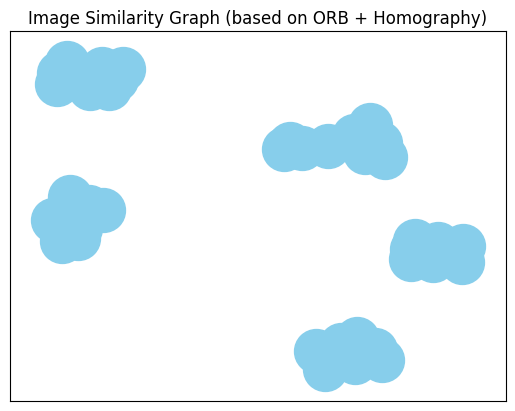

In [107]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add nodes (images)
for idx, frag in enumerate(fragments):
    G.add_node(idx, label=frag["file"])

# Add edges with weight = inliers
for i, j, H, inliers in edges:
    G.add_edge(i, j, weight=inliers)

# Position nodes using layout
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='skyblue')

# Draw edges (thickness = similarity)
weights = [G[u][v]['weight'] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w/90 for w in weights])

# Labels (image names)
#labels = {i: frag_files[i] for i in range(len(fragments))}
#nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Image Similarity Graph (based on ORB + Homography)")
plt.show()

# visualizing different groups

In [101]:
import networkx as nx

G = nx.Graph()

# Add nodes
for i in range(len(fragments)):
    G.add_node(i)

# Add only strong edges
MIN_EDGE_WEIGHT = 10   # tune this (8–15)
for i, j, H, inliers in edges:
    if inliers >= MIN_EDGE_WEIGHT:
        G.add_edge(i, j, weight=inliers)

In [102]:

components = list(nx.connected_components(G))
print(f"Total groups : {len(components)}")

Total groups : 5


In [ ]:
, 6, 8, 42, 11, 12, 29}print(components)

[{0, 33, 4, 6, 8, 42, 11, 12, 29}, {32, 1, 34, 37, 7, 41, 20, 22, 28}, {2, 3, 5, 9, 14, 15, 24, 25, 26}, {38, 40, 10, 13, 16, 17, 18, 30, 31}, {35, 36, 39, 43, 44, 19, 21, 23, 27}]


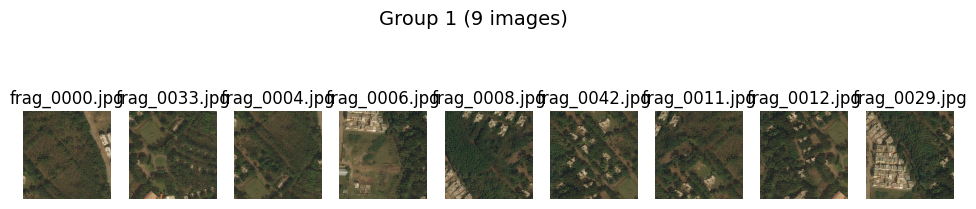

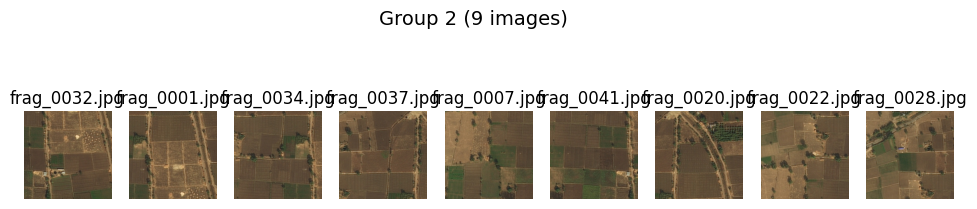

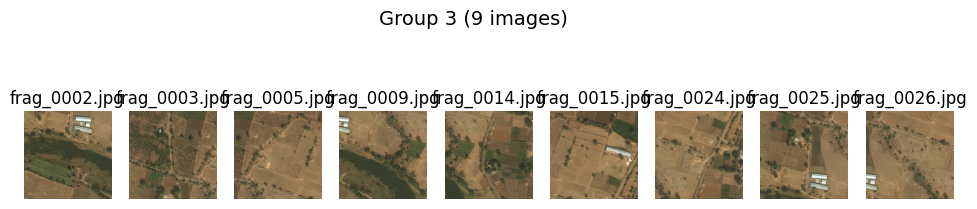

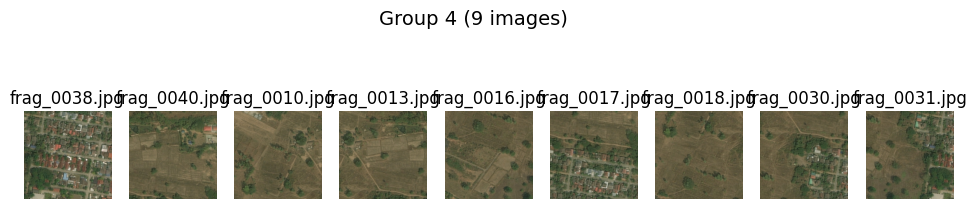

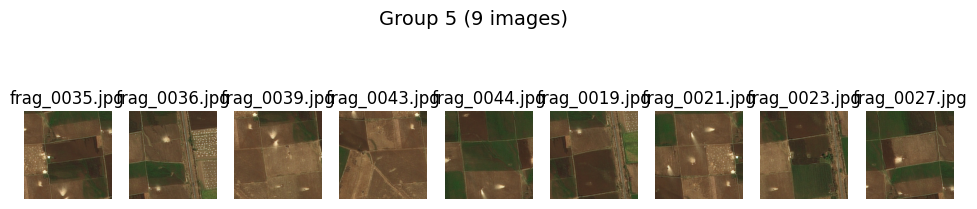

In [100]:
import matplotlib.pyplot as plt

for idx, comp in enumerate(components):
    comp = list(comp)
    n = len(comp)

    plt.figure(figsize=(12, 3))

    for i, node in enumerate(comp):
        plt.subplot(1, n, i+1)
        img = fragments[node]["img"]
        
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{frag_files[node]}")
        plt.axis("off")

    plt.suptitle(f"Group {idx+1} ({n} images)", fontsize=14)
    plt.show()

# Step 3 : STITCHING 

In [ ]:
def stitching(img) :
    stitcher = cv2.Stitcher_create()
    status , stitched_img = stitcher.stitch(img)
    if status == cv2.Stitcher_OK:
        return stitched_img
    else :
        print("Image stitching failed !!!!!" )
        return None


In [111]:
for idx, comp in enumerate(components):
    print(f"\nGroup {idx+1}:")
    
    for node in comp:
        print(os.path.join("fragments", frag_files[node]))


Group 1:
fragments\frag_0000.jpg
fragments\frag_0033.jpg
fragments\frag_0004.jpg
fragments\frag_0006.jpg
fragments\frag_0008.jpg
fragments\frag_0042.jpg
fragments\frag_0011.jpg
fragments\frag_0012.jpg
fragments\frag_0029.jpg

Group 2:
fragments\frag_0032.jpg
fragments\frag_0001.jpg
fragments\frag_0034.jpg
fragments\frag_0037.jpg
fragments\frag_0007.jpg
fragments\frag_0041.jpg
fragments\frag_0020.jpg
fragments\frag_0022.jpg
fragments\frag_0028.jpg

Group 3:
fragments\frag_0002.jpg
fragments\frag_0003.jpg
fragments\frag_0005.jpg
fragments\frag_0009.jpg
fragments\frag_0014.jpg
fragments\frag_0015.jpg
fragments\frag_0024.jpg
fragments\frag_0025.jpg
fragments\frag_0026.jpg

Group 4:
fragments\frag_0038.jpg
fragments\frag_0040.jpg
fragments\frag_0010.jpg
fragments\frag_0013.jpg
fragments\frag_0016.jpg
fragments\frag_0017.jpg
fragments\frag_0018.jpg
fragments\frag_0030.jpg
fragments\frag_0031.jpg

Group 5:
fragments\frag_0035.jpg
fragments\frag_0036.jpg
fragments\frag_0039.jpg
fragments\frag

In [ ]:
def stitch_group(group_indices, fragments, edges):
    # Build edge lookup for this group
    edge_map = {}
    for i, j, H, inliers in edges :
        if i in group_indices and j in group_indices:
            edge_map[(i,j)] = H
            edge_map[(j,i)] = np.linalg.inv(H)
    
    # Pick reference = first fragment (/ largest)
    ref = group_indices[0]
    H_to_ref = {ref: np.eye(3)}  # identity for reference

    # BFS to compute homography of every fragment relative to reference
    from collections import deque
    queue = deque([ref])
    visited = {ref}
    while queue:
        curr = queue.popleft()
        for neighbor in group_indices:
            if neighbor not in visited and (curr, neighbor) in edge_map:
                H_to_ref[neighbor] = H_to_ref[curr] @ edge_map[(curr, neighbor)]
                visited.add(neighbor)
                queue.append(neighbor)

# Find output canvas size
    all_corners = []
    for idx in group_indices:
        if idx not in H_to_ref:
            continue
        h, w = fragments[idx]["img"].shape[:2]
        corners = np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)
        warped_corners = cv2.perspectiveTransform(corners, H_to_ref[idx])
        all_corners.append(warped_corners)

    all_corners = np.concatenate(all_corners)
    x_min, y_min = all_corners.min(axis=0).ravel()
    x_max, y_max = all_corners.max(axis=0).ravel()

    # translation to everything in positive coords 
    tx, ty = -x_min , -y_min
    T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
    out_w, out_h = int(x_max - x_min), int(y_max - y_min)


        
